In [1]:
from pathlib import Path
import getpass
from datetime import datetime, timedelta
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.plot
from rasterio import features
from osgeo import gdal

from sentinelhub import (
    SHConfig,
    CRS,
    BBox,
    DataCollection,
    DownloadRequest,
    MimeType,
    MosaickingOrder,
    SentinelHubDownloadClient,
    SentinelHubStatisticalDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
    SentinelHubStatistical,
    Geometry,
    parse_time,
)

In [2]:
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session

from dotenv import load_dotenv
load_dotenv()

# Your client credentials
client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")

# Create a session
client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)

# Get token for the session
token = oauth.fetch_token(token_url='https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
                          client_secret=client_secret, include_client_id=True)

# All requests using this session will have an access token automatically added
resp = oauth.get("https://sh.dataspace.copernicus.eu/configuration/v1/wms/instances")
print(resp.content)

b'[]'


In [3]:
evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["CH4"],
    output: { bands: 1 },
  }
}

minVal = 1600
maxVal = 2000

function evaluatePixel(sample, scene) {
  return [(sample.CH4 - minVal) / (maxVal- minVal)]
}
"""

def request_single_day(bbox, date_str="2025-03-15", location_name="Poznan"):
    the_day = datetime.strptime(date_str, '%Y-%m-%d').date()
    next_day = the_day + timedelta(1)
    request = {
        "input": {
            "bounds": {
                "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
                "bbox": bbox,
            },
            "data": [
                {
                    "type": "sentinel-5p-l2",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{the_day.strftime('%Y-%m-%d')}T00:00:00Z",
                            "to": f"{next_day.strftime('%Y-%m-%d')}T00:00:00Z",
                        }
                    },
                    "processing": {"minQa": 20},
                }
            ],
        },
        "output": {
            "width": 512,
            "height": 512,
            "responses": [
                    {
                        "identifier": "default",
                        "format": {
                            "type": "image/tiff"
                        }
                    }
                ]
        },
        "evalscript": evalscript,
    }
    
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"
    response = oauth.post(url, json=request)
    if response.status_code == 200:
        os.makedirs("./data/", exist_ok = True)
        os.makedirs("./data/output_copernicus", exist_ok = True)
        os.makedirs(f"./data/output_copernicus/{location_name}", exist_ok = True)
        filename = f"./data/output_copernicus/{location_name}/{the_day.strftime('%Y-%m-%d')}_{location_name}.tiff"
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Methane data saved as {filename}")
    else:
        print("Error", response.json())
    return response

In [4]:
buffer = 2.5
warsaw_coords = [21.0-buffer, 52.0-buffer, 21.0+buffer, 52.0+buffer]
poznan_coords = [17.0-buffer, 52.5-buffer, 17.0+buffer, 52.5+buffer]
svalbard_coords = [9.0, 76.0, 33.6, 81.0]
bbox = svalbard_coords

def refresh_token():
    token = oauth.fetch_token(token_url='https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token',
                          client_secret=client_secret, include_client_id=True)

    # All requests using this session will have an access token automatically added
    resp = oauth.get("https://sh.dataspace.copernicus.eu/configuration/v1/wms/instances")
    print(resp.content)

def leading_zero(n):
    return f"0{n}" if n < 10 else f"{n}"

location_name = "Svalbard"
for y in [2023, 2024]:
    for m in range(1, 13):
        m = leading_zero(m)
        refresh_token()
        for d in range(1, 32):
            d = leading_zero(d)
            date = f"{y}-{m}-{d}"
            try:
                request = request_single_day(bbox, date, location_name)
            except:
                # print(request.content)
                print(f"There is no ({d}.{m})")


b'[]'
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-01_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-02_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-03_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-04_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-05_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-06_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-07_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-08_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-09_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-10_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-11_Svalbard.tiff
Methane data saved as ./data/output_copernicus/Svalbard/2023-01-12_Svalbard.tiff
Methane data saved as 

In [5]:
"""countries = (
    gpd.read_file("./data/ne_50m_admin_0_countries.shp")
    .to_crs(3857)
    .cx[bbox_europe.min_x : bbox_europe.max_x, bbox_europe.min_y : bbox_europe.max_y]
    .reset_index(drop=True)
)
countries = countries[["ADMIN", "geometry"]]"""


def plot_request(request, date):
    filename = f"./data/output_copernicus/Svalbard/2024-08-28_Svalbard.tiff"
    with rasterio.open(filename) as raster:
        fig, ax = plt.subplots(figsize=(10, 10))
        plt.title("CH4 concentration")
        ax.set_xlim([bbox[0], bbox[2]])
        ax.set_ylim([bbox[1], bbox[3]])
        rasterio.plot.show(raster, ax=ax)
        #countries.plot(ax=ax, facecolor="none", edgecolor="black")


def read_geotiff(filename):
    ds = gdal.Open(filename)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    return arr, ds

def show_plot(arr, title=""):
    plt.imshow(arr)
    plt.title(title)
    plt.colorbar()
    plt.show()

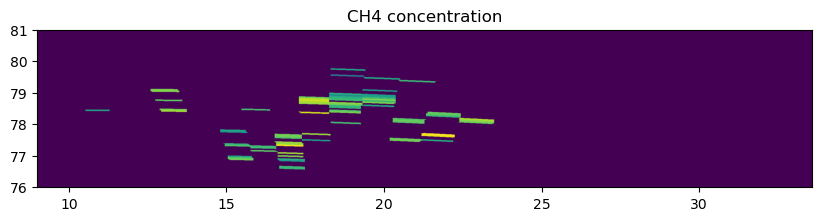

In [6]:
plot_request(request, date)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


/home/hiroselab/miniconda3/envs/convlstm/lib/python3.13/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


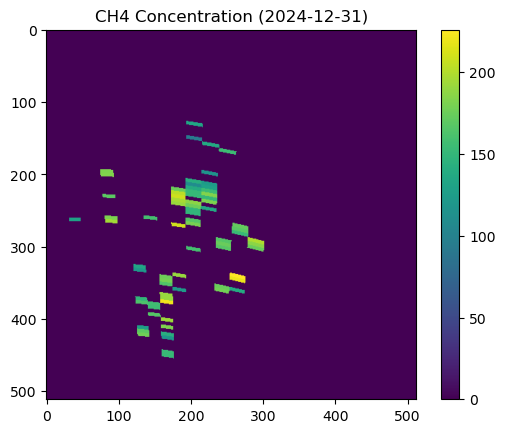

In [7]:
arr, ds = read_geotiff(f"./data/output_copernicus/Svalbard/2024-08-28_Svalbard.tiff")
print(arr)
show_plot(arr, title=f"CH4 Concentration ({date})")

In [8]:
from dateutil.relativedelta import relativedelta

evalscript_mean_mosaic = """
//VERSION=3
function setup() {
    return {
        input: ["CH4", "dataMask"],
        output: {
            bands: 1,
            sampleType: "FLOAT32",
        },
        mosaicking: "ORBIT"
    };
}

function isClear(sample) {
    return sample.dataMask == 1;
}

function sum(array) {
    let sum = 0;
    for (let i = 0; i < array.length; i++) {
        sum += array[i].CH4;
    }
    return sum;
}

function evaluatePixel(samples) {
    const clearTs = samples.filter(isClear)
    const mean = sum(clearTs) / clearTs.length
    const minVal = 1600
    const maxVal = 2000
    return [(mean - minVal) / (maxVal- minVal)]
}
"""


def request_mean_month(bbox, date_str="2025-03", location_name="Poznan"):
    the_date = datetime.strptime(date_str, '%Y-%m').date()
    next_date = the_date + relativedelta(months=1)
    request = {
        "input": {
            "bounds": {
                "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
                "bbox": bbox,
            },
            "data": [
                {
                    "type": "sentinel-5p-l2",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{the_date.strftime('%Y-%m')}-01T00:00:00Z",
                            "to": f"{next_date.strftime('%Y-%m')}-01T00:00:00Z",
                        }
                    },
                    "processing": {"minQa": 10},
                }
            ],
        },
        "output": {
            "width": 512,
            "height": 512,
            "responses": [
                    {
                        "identifier": "default",
                        "format": {
                            "type": "image/tiff"
                        }
                    }
                ]
        },
        "evalscript": evalscript_mean_mosaic,
    }
    
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"
    response = oauth.post(url, json=request)
    if response.status_code == 200:
        os.makedirs("./data/", exist_ok = True)
        os.makedirs("./data/output_copernicus_mean/", exist_ok = True)
        os.makedirs(f"./data/output_copernicus_mean/{location_name}", exist_ok = True)
        filename = f"./data/output_copernicus_mean/{location_name}/{the_date.strftime('%Y-%m')}_{location_name}_mean.tiff"
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Methane data saved as: {filename}")
    else:
        print("Error: ", response.json())
    return response

In [9]:
buffer = 2.5
warsaw_coords = [21.0-buffer, 52.0-buffer, 21.0+buffer, 52.0+buffer]
poznan_coords = [17.0-buffer, 52.5-buffer, 17.0+buffer, 52.5+buffer]
svalbard_coords = [9.0, 76.0, 33.6, 81.0]
bbox = svalbard_coords

location_name = "Svalbard"
for y in range(2016, 2026):
    for m in range(1, 13):
        m = leading_zero(m)
        refresh_token()
        date = f"{y}-{m}"
        try:
            request = request_mean_month(bbox, date, location_name)
        except:
            # print(request.content)
            print(f"There is no ({y}.{m})")
    
    #arr, ds = read_geotiff(f"./ch4_data/ch4_mean_Poznan_{month}.tiff")
    #print(arr)
    #show_plot(arr, title=f"Mean CH4 Concentration ({month})")

b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-01_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-02_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-03_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-04_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-05_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-06_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-07_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-08_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-09_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_copernicus_mean/Svalbard/2016-10_Svalbard_mean.tiff
b'[]'
Methane data saved as: ./data/output_coperni